In [40]:
# Importera bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [41]:
# Ladda in Fashion MNIST

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()


print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Antal klasser:", len(np.unique(y_train_full)))
print("Klasser:", np.unique(y_train_full))

X_train_full: (60000, 28, 28)
y_train_full: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)
Antal klasser: 10
Klasser: [0 1 2 3 4 5 6 7 8 9]


In [42]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

for i, name in enumerate(class_names):
    print(i, name)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


In [43]:
class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distrubtion = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name":[class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distrubtion

,class_id,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


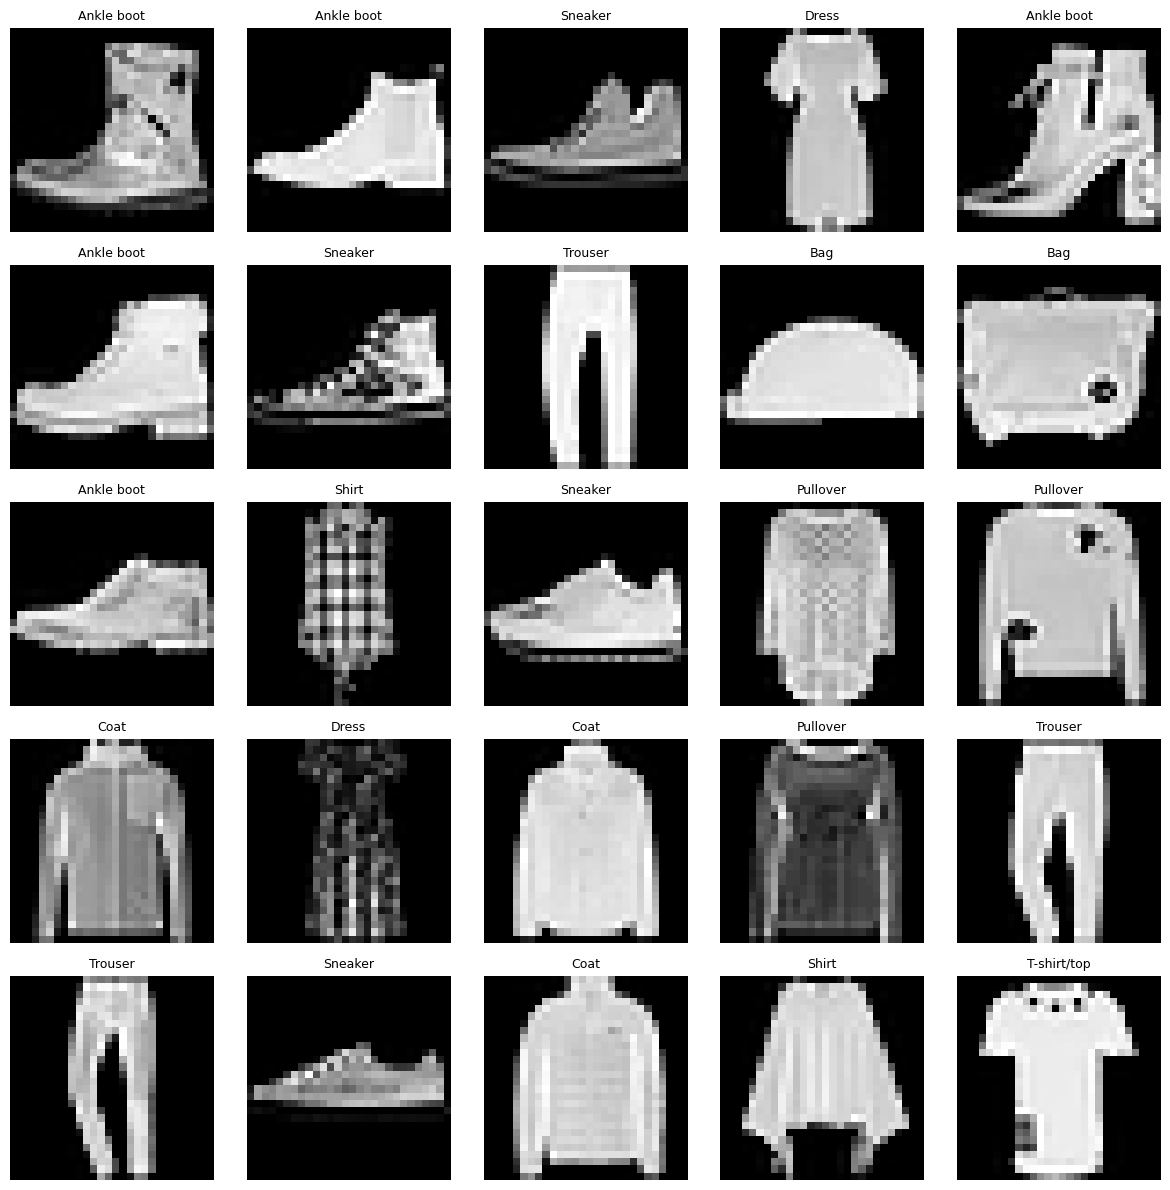

In [44]:
def plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices=rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index], cmap="gray")
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_image_grid(
        X_train_full,
        y_train_full,
        class_names,
        n_images=25
    )


In [45]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full, 
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [46]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") /255.0
X_test = X_test.astype("float32") /255.0

print("Minsta värdet efter normalisering", X_train.min())
print("Största värdet efter normalisering", X_train.max())

Minsta värdet efter normalisering 0.0
Största värdet efter normalisering 1.0


In [47]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

X_train shape efter kanal-dimension: (54000, 28, 28, 1)
X_val shape efter kanal-dimension: (6000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


In [48]:
print("Exempel på labels:", y_train[:10])

Exempel på labels: [8 9 8 0 1 9 4 6 6 8]


In [49]:
baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

In [50]:
baseline_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [52]:
history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8312 - loss: 0.4690 - val_accuracy: 0.8917 - val_loss: 0.3095
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8902 - loss: 0.3026 - val_accuracy: 0.9023 - val_loss: 0.2675
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9035 - loss: 0.2645 - val_accuracy: 0.8902 - val_loss: 0.3045
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9129 - loss: 0.2343 - val_accuracy: 0.9077 - val_loss: 0.2471
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9226 - loss: 0.2115 - val_accuracy: 0.9167 - val_loss: 0.2308
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9299 - loss: 0.1913 - val_accuracy: 0.9190 - val_loss: 0.2244
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9375 - loss: 0.1718 - val_accuracy: 0.9127 - val_loss: 0.2459
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9413 - loss: 0.1580 - val_a

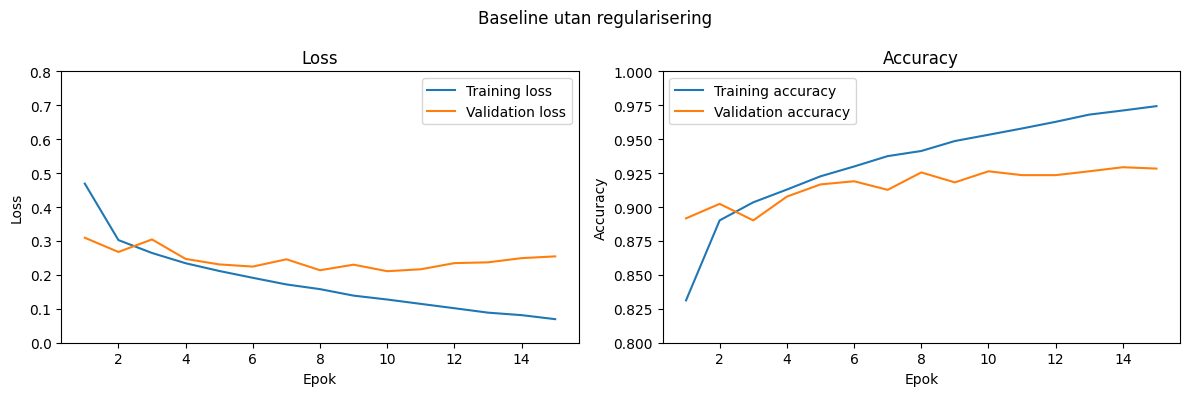

In [53]:
def plot_history(history, title="Träningskurvor", filename=None):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.ylim(0.0, 0.8)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.ylim(0.80, 1.00)
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    
    if filename is not None:
        plt.savefig(filename, bbox_inches="tight", dpi=150)

    plt.show()

plot_history(
    history_baseline,
    "Baseline utan regularisering",
)

## Analys – Baseline

Baseline-modellen gav relativt hög accuracy, men träningskurvorna visar tydliga tecken på overfitting.

Training loss fortsätter att minska medan validation loss planar ut och börjar öka igen efter några epoker. Training accuracy fortsätter också att öka, medan validation accuracy stannar av.

Det betyder att modellen lär sig träningsdatan bättre och bättre, men inte förbättras lika mycket på ny data.

In [54]:
dropout02_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
 
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.20),
 
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.20),
 
    layers.Flatten(),
 
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),
 
    layers.Dense(10, activation="softmax")
])
 
dropout02_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
 
 
dropout02_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8005 - loss: 0.5570 - val_accuracy: 0.8722 - val_loss: 0.3505
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8684 - loss: 0.3675 - val_accuracy: 0.8915 - val_loss: 0.2929
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8838 - loss: 0.3199 - val_accuracy: 0.9087 - val_loss: 0.2504
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8956 - loss: 0.2900 - val_accuracy: 0.9052 - val_loss: 0.2492
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9018 - loss: 0.2698 - val_accuracy: 0.9153 - val_loss: 0.2271
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9071 - loss: 0.2553 - val_accuracy: 0.9103 - val_loss: 0.2400
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9097 - loss: 0.2440 - val_accuracy: 0.9198 - val_loss: 0.2125
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9143 - loss: 0.2312 - 

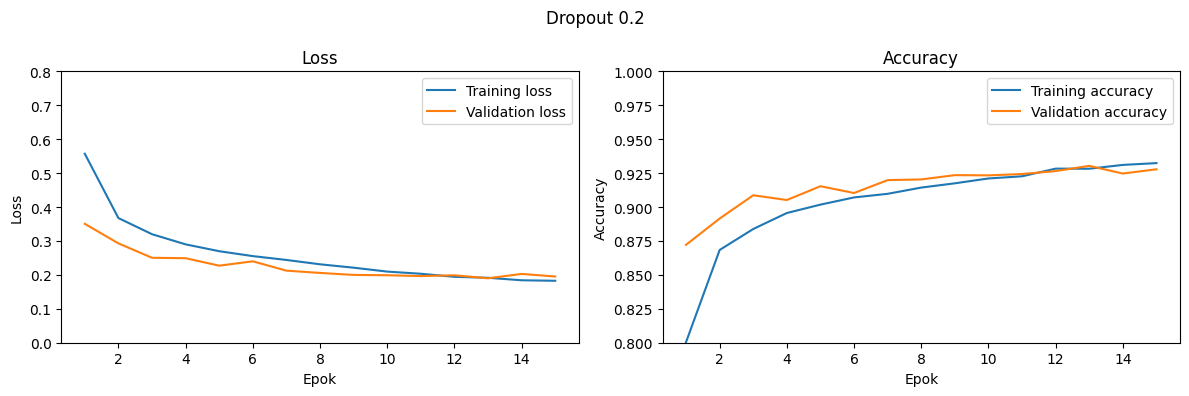

In [55]:
history_dropout02 = dropout02_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

plot_history(history_dropout02, "Dropout 0.2")

## Analys – Dropout 0.2

Dropout 0.2 gav bättre generalisering än baseline-modellen.

Validation accuracy blev stabilare samtidigt som modellen fortfarande kunde lära sig viktiga mönster i datan. Skillnaden mellan training accuracy och validation accuracy blev mindre jämfört med baseline-modellen.

I vår körning gav denna modell bäst test accuracy.

In [56]:
dropout05_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
 
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.50),
 
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.50),
 
    layers.Flatten(),
 
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.50),
 
    layers.Dense(10, activation="softmax")
])
 
dropout05_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
 
 
dropout05_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7177 - loss: 0.7646 - val_accuracy: 0.8402 - val_loss: 0.4452
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8038 - loss: 0.5401 - val_accuracy: 0.8682 - val_loss: 0.3698
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8211 - loss: 0.4882 - val_accuracy: 0.8772 - val_loss: 0.3333
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8343 - loss: 0.4552 - val_accuracy: 0.8828 - val_loss: 0.3141
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8461 - loss: 0.4274 - val_accuracy: 0.8992 - val_loss: 0.2857
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8523 - loss: 0.4066 - val_accuracy: 0.8975 - val_loss: 0.2753
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8580 - loss: 0.3922 - val_accuracy: 0.8958 - val_loss: 0.2749
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8633 - loss: 0.3835 - va

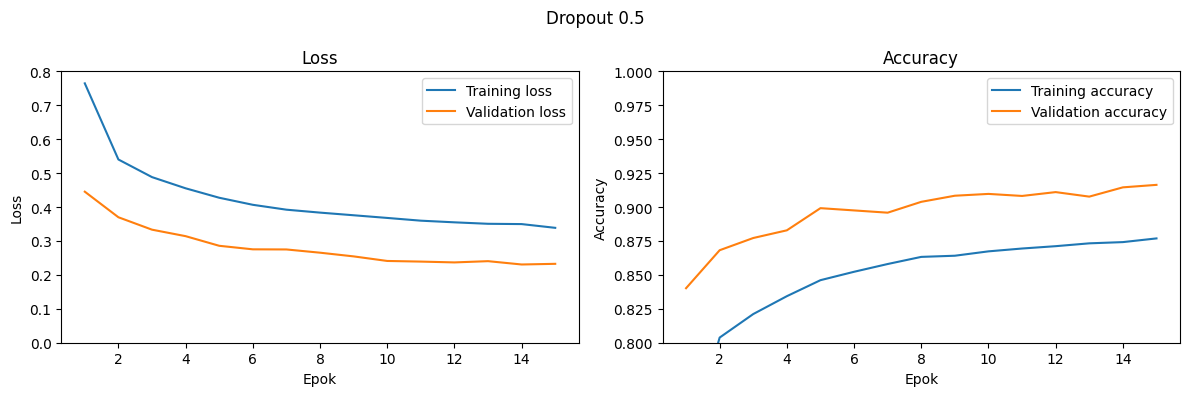

In [57]:
history_dropout05 = dropout05_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

plot_history(history_dropout05, "Dropout 0.5")

## Analys – Dropout 0.5

Dropout 0.5 gav starkare regularisering än dropout 0.2.

Modellen blev mer stabil men också något mindre flexibel. Validation accuracy förbättrades inte lika mycket som för dropout 0.2, vilket tyder på att för mycket dropout kan göra det svårare för modellen att lära sig effektivt.

Detta visar att regularisering behöver balanseras för att modellen fortfarande ska kunna lära sig viktiga mönster i datan.

In [58]:
l2_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
 
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(0.001)
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
    
 
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(0.001)
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
 
    layers.Flatten(),
 
    layers.Dense(64, activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
    ),
    
 
    layers.Dense(10, activation="softmax")
])
 
l2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
 
 
l2_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8198 - loss: 0.6184 - val_accuracy: 0.8750 - val_loss: 0.4624
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8759 - loss: 0.4511 - val_accuracy: 0.8895 - val_loss: 0.4107
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8834 - loss: 0.4166 - val_accuracy: 0.8925 - val_loss: 0.3935
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8892 - loss: 0.3936 - val_accuracy: 0.8888 - val_loss: 0.3906
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8950 - loss: 0.3801 - val_accuracy: 0.8973 - val_loss: 0.3716
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8976 - loss: 0.3690 - val_accuracy: 0.9057 - val_loss: 0.3526
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9029 - loss: 0.3554 - val_accuracy: 0.8920 - val_loss: 0.3683
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9034 - loss: 0.3510 - val_accu

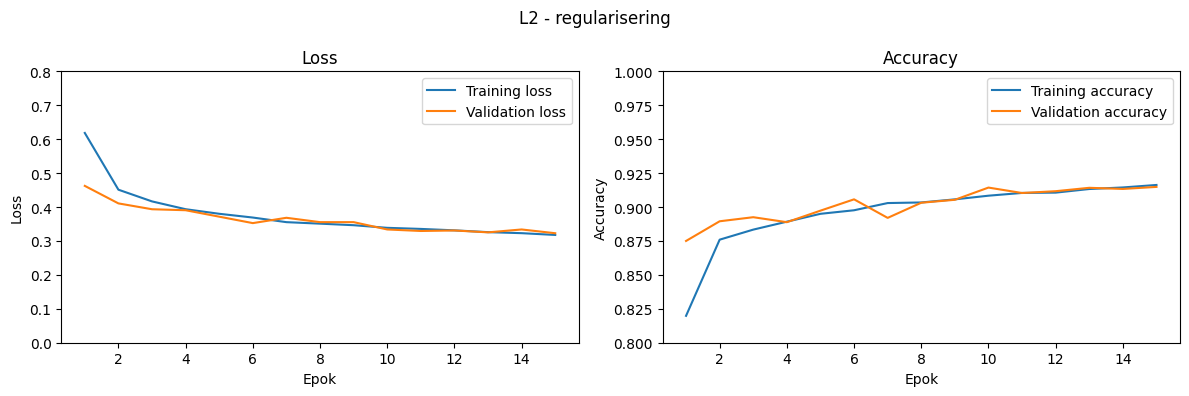

In [59]:
history_l2_model =l2_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

plot_history(history_l2_model, "L2 - regularisering")

## Analys – L2-regularisering

L2-regularisering hjälpte modellen att generalisera bättre och minska risken för overfitting.

Träningskurvorna visar att training accuracy och validation accuracy ligger relativt nära varandra under hela träningen, vilket tyder på stabil generalisering till ny data.

Modellen tränades stabilt och gav relativt jämna resultat mellan träning och validation.

In [60]:
early_stopping_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
 
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
    
 
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same",
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
 
    layers.Flatten(),
 
    layers.Dense(64, activation="relu"),
    
 
    layers.Dense(10, activation="softmax")
])
 
early_stopping_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)



early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
 
early_stopping_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8313 - loss: 0.4743 - val_accuracy: 0.8887 - val_loss: 0.3218
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8879 - loss: 0.3143 - val_accuracy: 0.9025 - val_loss: 0.2762
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9039 - loss: 0.2675 - val_accuracy: 0.9113 - val_loss: 0.2500
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9134 - loss: 0.2382 - val_accuracy: 0.9163 - val_loss: 0.2322
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9229 - loss: 0.2125 - val_accuracy: 0.9212 - val_loss: 0.2276
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9289 - loss: 0.1944 - val_accuracy: 0.9243 - val_loss: 0.2203
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9363 - loss: 0.1731 - val_accuracy: 0.9240 - val_loss: 0.2162
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9428 - loss: 0.1567 - val_accur

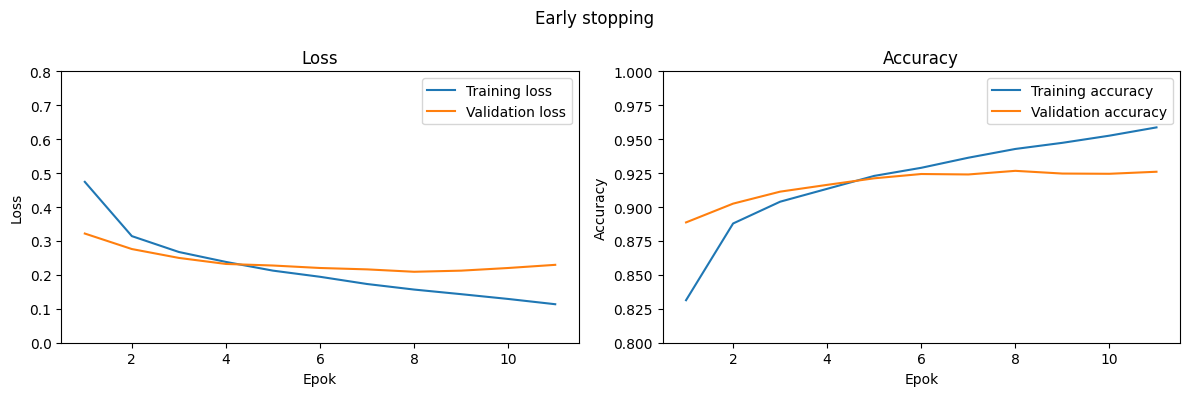

In [61]:
history_early_stopping = early_stopping_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stopping_callback]
)

plot_history(history_early_stopping, "Early stopping")

## Analys – Early stopping

Early stopping används för att övervaka validation loss under träningen.

Om validation loss slutar förbättras under flera epoker kan träningen stoppas automatiskt för att minska risken för overfitting.

I våra träningskurvor ser vi att training loss fortsätter att minska medan validation loss planar ut efter några epoker. Det visar att modellen börjar lära sig träningsdatan bättre än validation-datan.

Early stopping är därför en metod som kan hjälpa modellen att generalisera bättre till ny data.

In [62]:
l1_l2_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
 
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l1_l2(l1=0.000001, l2=0.0001)
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
    
 
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l1_l2(l1=0.000001, l2=0.0001)
    ),
 
    layers.MaxPooling2D(pool_size=(2, 2)),
 
    layers.Flatten(),
 
    layers.Dense(64, activation="relu",
    kernel_regularizer=regularizers.l1_l2(l1=0.000001, l2=0.0001)
    ),
    
 
    layers.Dense(10, activation="softmax")
])
 
l1_l2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
 
 
l1_l2_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8333 - loss: 0.4909 - val_accuracy: 0.8860 - val_loss: 0.3515
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8883 - loss: 0.3430 - val_accuracy: 0.9067 - val_loss: 0.2926
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9036 - loss: 0.3068 - val_accuracy: 0.9125 - val_loss: 0.2866
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9115 - loss: 0.2852 - val_accuracy: 0.9163 - val_loss: 0.2757
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9201 - loss: 0.2647 - val_accuracy: 0.9172 - val_loss: 0.2679
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9225 - loss: 0.2558 - val_accuracy: 0.9170 - val_loss: 0.2743
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9301 - loss: 0.2419 - val_accuracy: 0.9177 - val_loss: 0.2837
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9342 - loss: 0.2334 - val_ac

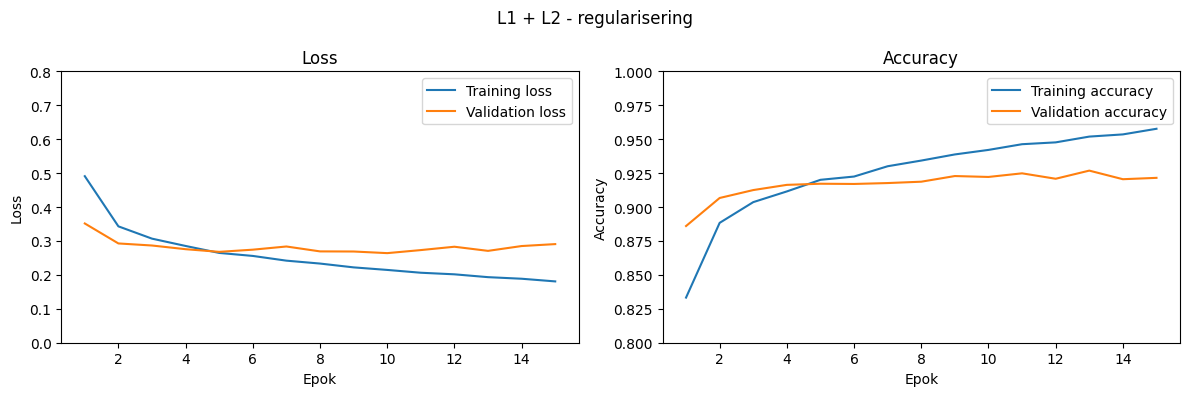

In [63]:
history_l1_l2_model = l1_l2_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

plot_history(history_l1_l2_model, "L1 + L2 - regularisering")

## Analys – L1 + L2 regularisering

L1 + L2 regularisering kombinerar två olika regulariseringsmetoder för att minska risken för overfitting.

L2 försöker göra modellens vikter mindre medan L1 även kan pressa vissa vikter närmare noll. Syftet är att göra modellen mindre komplex och förbättra generaliseringen till ny data.

I träningskurvorna ser vi att validation accuracy ligger relativt stabilt under träningen samtidigt som training accuracy fortsätter att öka. Validation loss planar också ut tidigare än training loss.

Det visar att modellen generaliserar relativt stabilt men också att för stark regularisering kan begränsa modellens inlärning om regulariseringsvärdena blir för höga.

In [64]:
import os
os.makedirs("models", exist_ok=True)
os.makedirs("images", exist_ok=True)

In [65]:
baseline_model.save("models/baseline_model.keras")
dropout02_model.save("models/dropout_02_model.keras")
dropout05_model.save("models/dropout_05_model.keras")
early_stopping_model.save("models/early_stopping_model.keras")
l2_model.save("models/l2_model.keras")
l1_l2_model.save("models/l1_l2_model.keras")

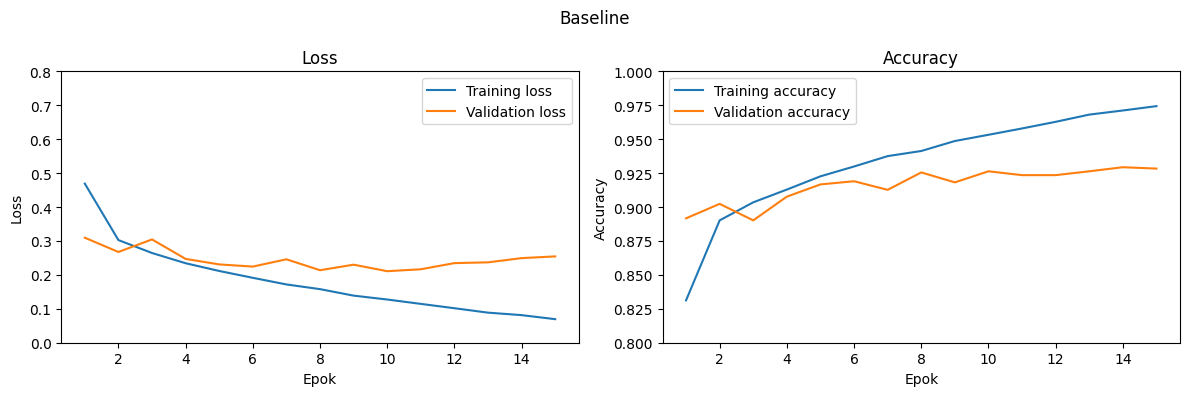

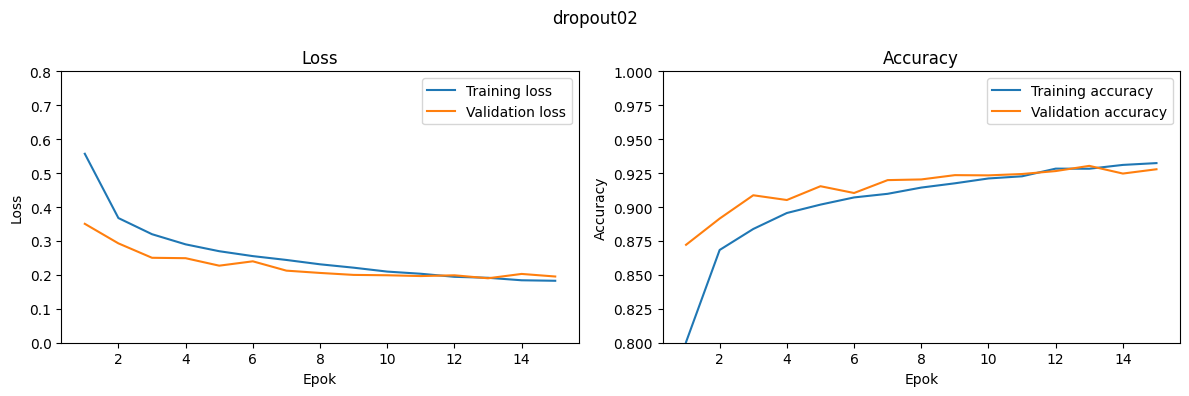

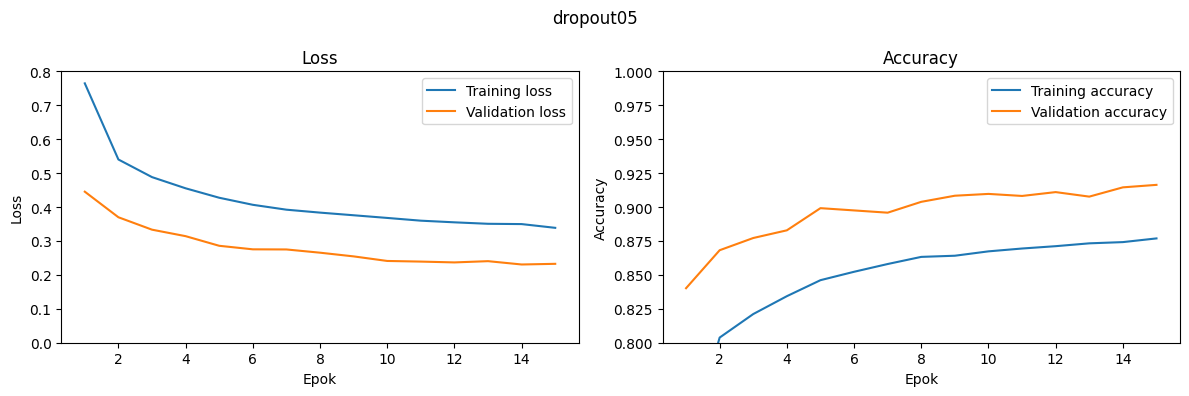

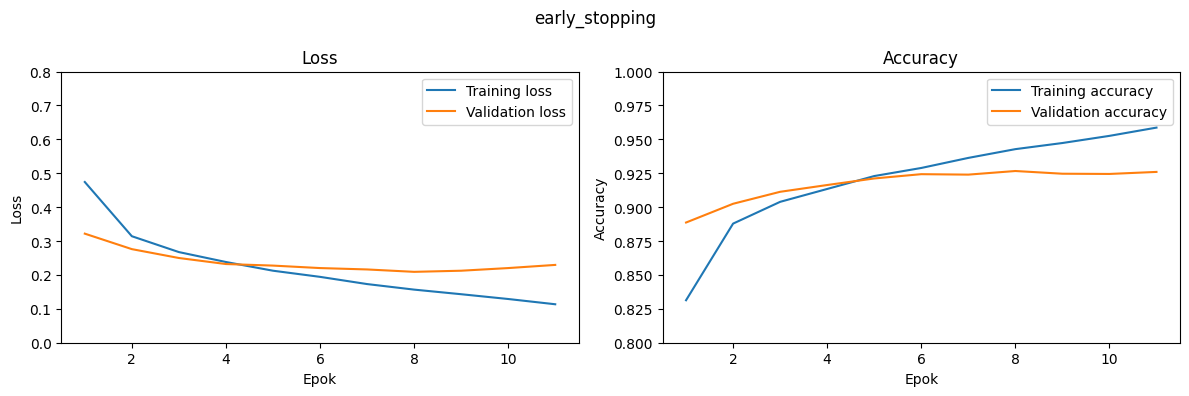

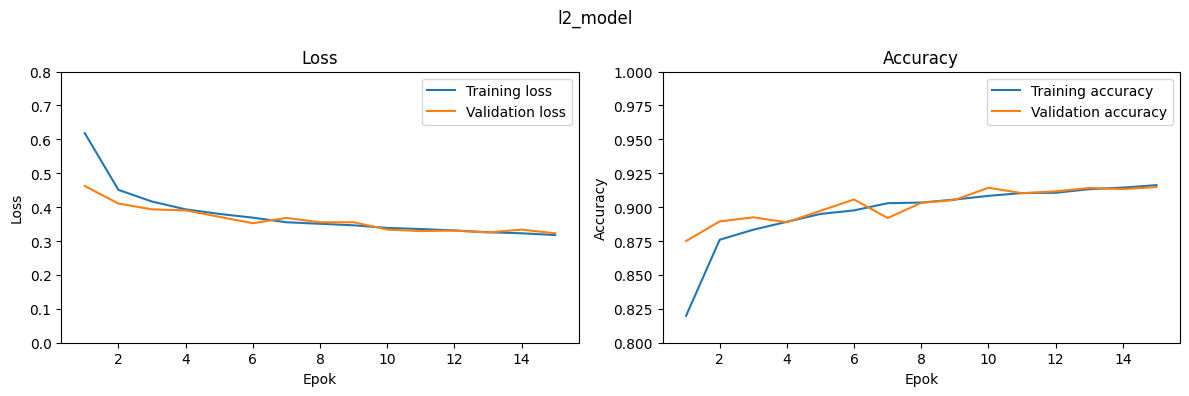

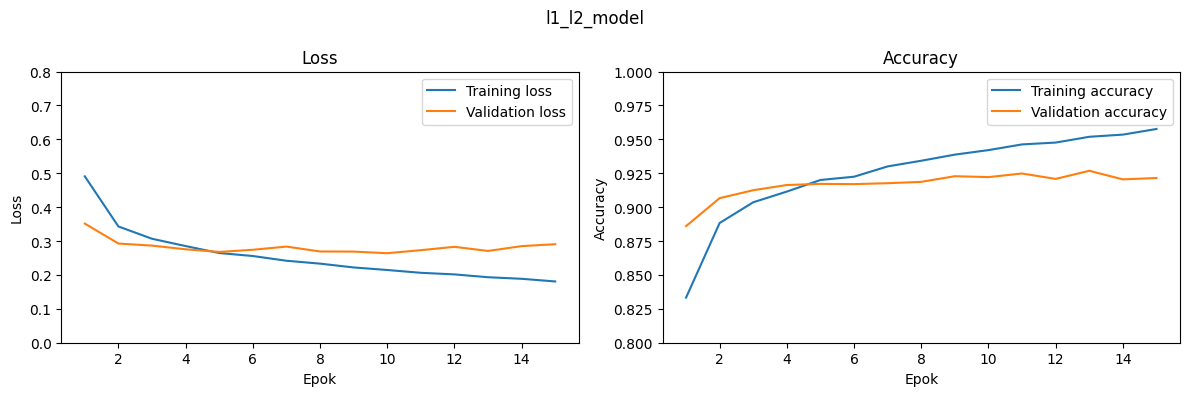

In [66]:
plot_history(history_baseline, "Baseline", "images/baseline_curves.png")
plot_history(history_dropout02, "dropout02", "images/dropout02_curves.png")
plot_history(history_dropout05, "dropout05", "images/dropout05_curves.png")
plot_history(history_early_stopping, "early_stopping", "images/early_stopping_curves.png")
plot_history(history_l2_model, "l2_model", "images/l2_model_curves.png")
plot_history(history_l1_l2_model, "l1_l2_model", "images/l1_l2_model_curves.png")

In [67]:
results = []

models = [
    ("Baseline", baseline_model),
    ("Dropout 0.2", dropout02_model),
    ("Dropout 0.5", dropout05_model),  
    ("Early stopping", early_stopping_model),
    ("l2 regularisering", l2_model),
    ("l1 + l2", l1_l2_model)
]

for model_name, model in models:
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    results.append({
        "model": model_name,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="test_accuracy", ascending=False)

results_df

,model,test_loss,test_accuracy
1,Dropout 0.2,0.221501,0.9214
0,Baseline,0.288552,0.9204
3,Early stopping,0.243533,0.9146
5,l1 + l2,0.323963,0.9146
2,Dropout 0.5,0.267137,0.9089
4,l2 regularisering,0.350609,0.9078


In [68]:
def predict_classes(model, X):
    proba = model.predict(X)
    pred = np.argmax(proba, axis=1)

    return pred, proba

In [69]:
best_model = dropout02_model
best_model_name = "Dropout 0.2"

final_test_pred, final_test_proba = predict_classes(
    best_model,
    X_test
)

i = 0

print("Predikterad klass:", final_test_pred[i], class_names[final_test_pred[i]])
print("Rätt klass:", y_test[i], class_names[y_test[i]])

print("Sannolikheter:")
for class_id, proba in enumerate(final_test_proba[i]):
    print(f"{class_id} - {class_names[class_id]}: {proba:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predikterad klass: 9 Ankle boot
Rätt klass: 9 Ankle boot
Sannolikheter:
0 - T-shirt/top: 0.0000
1 - Trouser: 0.0000
2 - Pullover: 0.0000
3 - Dress: 0.0000
4 - Coat: 0.0000
5 - Sandal: 0.0000
6 - Shirt: 0.0000
7 - Sneaker: 0.0002
8 - Bag: 0.0000
9 - Ankle boot: 0.9998


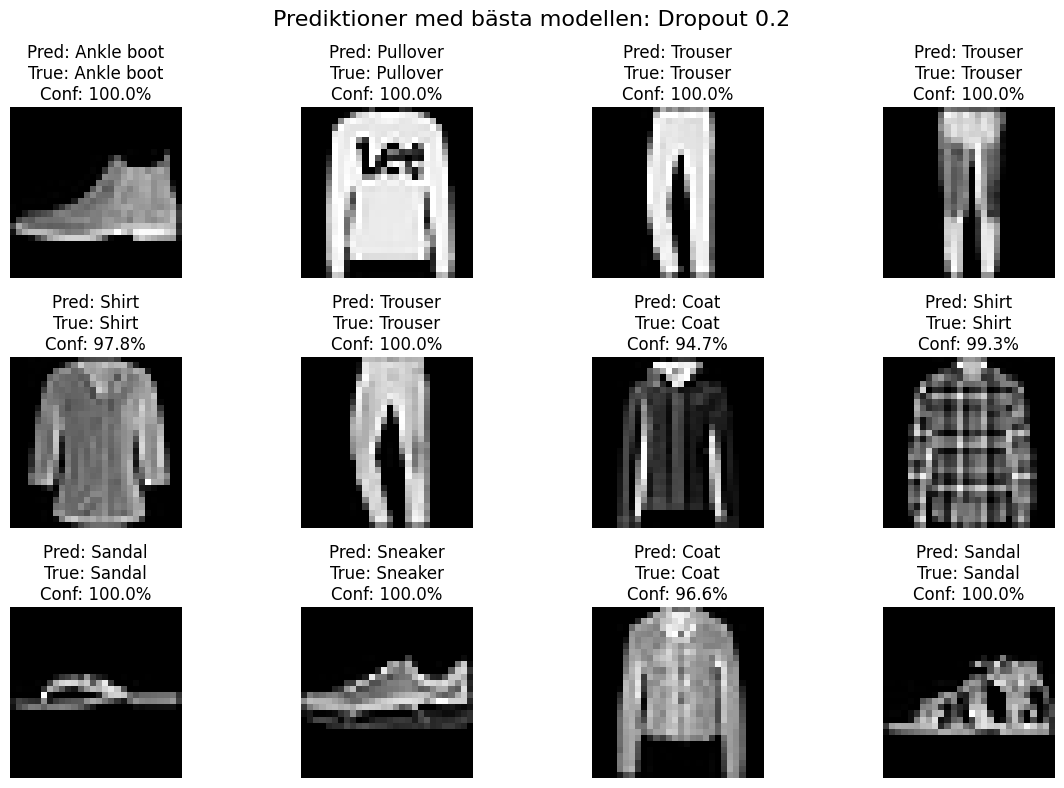

In [70]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    pred_label = final_test_pred[i]
    true_label = y_test[i]
    confidence = np.max(final_test_proba[i]) *100

    plt.title(
        f"Pred: {class_names[pred_label]}\n"
        f"True: {class_names[true_label]}\n"
        f"Conf: {confidence:.1f}%"
    )

    plt.axis("off")

plt.suptitle(f"Prediktioner med bästa modellen: {best_model_name}", fontsize=16)
plt.tight_layout()
plt.savefig("images/prediction_examples.png", bbox_inches="tight", dpi=150)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

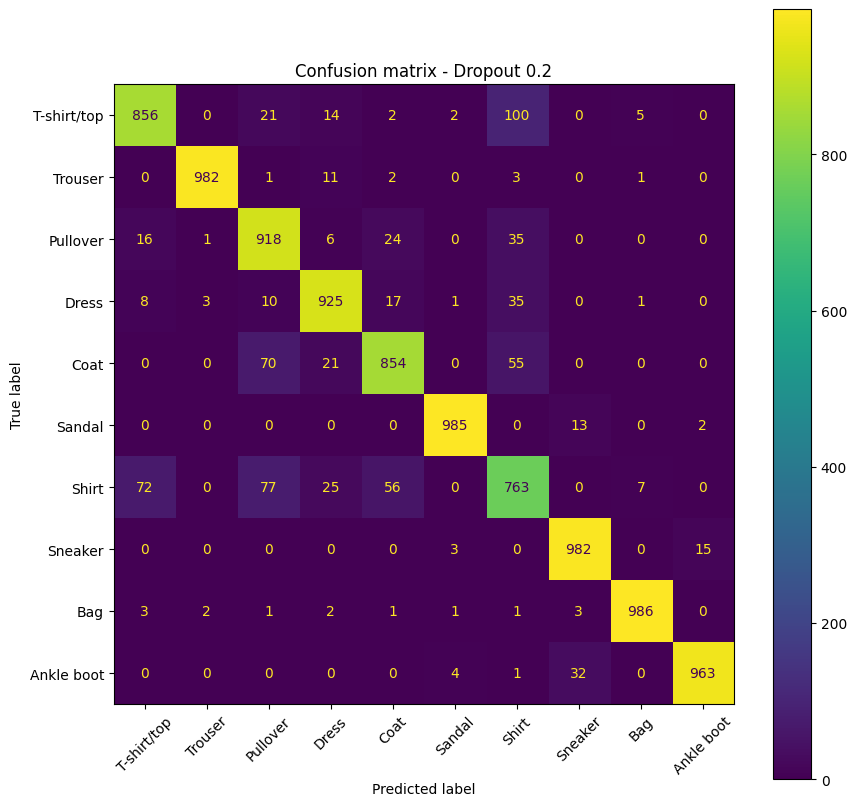

In [71]:
final_test_cm = confusion_matrix(
    y_test,
    final_test_pred
)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_test_cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(f"Confusion matrix - {best_model_name}")
plt.show

# Slutsats

Syftet med projektet var att undersöka hur olika regulariseringstekniker påverkar en CNN-modells förmåga att generalisera till ny data och minska risken för overfitting.

Vi testade flera olika modeller:
- baseline utan regularisering
- dropout 0.2
- dropout 0.5
- early stopping
- L2-regularisering
- samt L1 + L2 regularisering.

Resultaten visade att regularisering generellt förbättrade modellernas generalisering och gjorde modellerna mer stabila på validation- och testdata.

Dropout 0.2 gav bäst resultat i vår körning och gav en bra balans mellan inlärning och regularisering. Dropout 0.5 gav starkare regularisering men gjorde modellen något mindre flexibel.

Early stopping visade hur träningen kan övervakas för att minska risken för overfitting när validation loss slutar förbättras.

Vi såg också tydligt hur viktig regulariseringsstyrkan är i L1 + L2-modellen. När vi först testade modellen använde vi regulariseringsvärden som var för höga. Det gjorde att modellen blev för hårt begränsad och hade svårt att lära sig mönstren i datan. Accuracy blev därför mycket låg samtidigt som loss blev hög.

För att förbättra modellen sänkte vi regulariseringsvärdena. Det gjorde att modellen blev mindre hårt bestraffad och kunde lära sig bättre från träningsdatan. Efter ändringen förbättrades resultaten tydligt.

Confusion matrixen visade att modellen fungerade bäst på vissa klasser, exempelvis Sandal och Ankle boot, medan klasser som Shirt och T-shirt/top oftare blandades ihop eftersom de visuellt liknar varandra.

Projektet gav oss en bättre förståelse för:
- CNN-modeller
- regularisering
- overfitting och underfitting
- samt hur olika regulariseringstekniker påverkar modellens resultat.